# **------------------Assignment 03 — Decision Tree & K-Means------------------**


## **Task 01 — Decision Tree (Mushroom Dataset)**

### **1.1 Data Loading & Preprocessing**

#### **Part a) of 1.1**

In [ ]:
# Import Libraries
import numpy as np
import pandas as pd
import urllib.request
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# Download dataset (from "https://archive.ics.uci.edu/ml/machine-learning-databases/mushroom/agaricus-lepiota.data" file)
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/mushroom/agaricus-lepiota.data"
urllib.request.urlretrieve(url, "mushroom.csv")


('mushroom.csv', <http.client.HTTPMessage at 0x7922a8b49460>)

In [ ]:
# Column names (from "https://archive.ics.uci.edu/ml/machine-learning-databases/mushroom/agaricus-lepiota.names" file)
columns = [
'class','cap-shape','cap-surface','cap-color','bruises','odor',
'gill-attachment','gill-spacing','gill-size','gill-color',
'stalk-shape','stalk-root','stalk-surface-above-ring',
'stalk-surface-below-ring','stalk-color-above-ring',
'stalk-color-below-ring','veil-type','veil-color','ring-number',
'ring-type','spore-print-color','population','habitat'
]

In [ ]:
# Read Data from the CSV file
df = pd.read_csv("mushroom.csv", header=None, names=columns)

In [ ]:
# Print Data from CSV file
print(df.head())
print(df.shape)
print(df['class'].value_counts())

  class cap-shape cap-surface cap-color bruises odor gill-attachment  \
0     p         x           s         n       t    p               f   
1     e         x           s         y       t    a               f   
2     e         b           s         w       t    l               f   
3     p         x           y         w       t    p               f   
4     e         x           s         g       f    n               f   

  gill-spacing gill-size gill-color  ... stalk-surface-below-ring  \
0            c         n          k  ...                        s   
1            c         b          k  ...                        s   
2            c         b          n  ...                        s   
3            c         n          n  ...                        s   
4            w         b          k  ...                        s   

  stalk-color-above-ring stalk-color-below-ring veil-type veil-color  \
0                      w                      w         p          w   
1       

#### **Part b) of 1.1**

In [ ]:
# Print data in which missing values are not handled
selected_cols = df.columns[[0,1,2,3,4,9,11]]
print(df.loc[df.index[-30:], selected_cols])

     class cap-shape cap-surface cap-color bruises gill-color stalk-root
8094     e         b           s         g       f          g          ?
8095     p         x           y         c       f          y          c
8096     e         k           f         w       f          w          ?
8097     p         k           y         n       f          b          ?
8098     p         k           s         e       f          b          ?
8099     e         k           f         w       f          w          ?
8100     e         f           s         n       f          o          ?
8101     p         k           s         e       f          b          ?
8102     e         x           s         n       f          y          ?
8103     e         k           s         n       f          y          ?
8104     e         k           s         n       f          y          ?
8105     e         k           s         n       f          y          ?
8106     e         k           s         n       f 

In [ ]:
# Handle Missimg Values by replacing the ? with the mode of that column
for col in df.columns:
    if '?' in df[col].values:
        mode = df[col].mode()[0]
        df[col] = df[col].replace('?', mode)

In [ ]:
# Print Data in which missing values are handeled
selected_cols = df.columns[[0,1,2,3,4,9,11]]
print(df.loc[df.index[-30:], selected_cols])

     class cap-shape cap-surface cap-color bruises gill-color stalk-root
8094     e         b           s         g       f          g          b
8095     p         x           y         c       f          y          c
8096     e         k           f         w       f          w          b
8097     p         k           y         n       f          b          b
8098     p         k           s         e       f          b          b
8099     e         k           f         w       f          w          b
8100     e         f           s         n       f          o          b
8101     p         k           s         e       f          b          b
8102     e         x           s         n       f          y          b
8103     e         k           s         n       f          y          b
8104     e         k           s         n       f          y          b
8105     e         k           s         n       f          y          b
8106     e         k           s         n       f 

#### **Part c) of 1.1**

In [ ]:
# Label Encoding (Manual — NO sklearn)
encoders = {}

for col in df.columns:
    unique_vals = df[col].unique()
    mapping = {val: idx for idx, val in enumerate(unique_vals)}
    encoders[col] = mapping
    df[col] = df[col].map(mapping)

In [ ]:
# Print Encoders values
for col, encoder in encoders.items():
    print(f"{col}: {encoder}")

class: {'p': 0, 'e': 1}
cap-shape: {'x': 0, 'b': 1, 's': 2, 'f': 3, 'k': 4, 'c': 5}
cap-surface: {'s': 0, 'y': 1, 'f': 2, 'g': 3}
cap-color: {'n': 0, 'y': 1, 'w': 2, 'g': 3, 'e': 4, 'p': 5, 'b': 6, 'u': 7, 'c': 8, 'r': 9}
bruises: {'t': 0, 'f': 1}
odor: {'p': 0, 'a': 1, 'l': 2, 'n': 3, 'f': 4, 'c': 5, 'y': 6, 's': 7, 'm': 8}
gill-attachment: {'f': 0, 'a': 1}
gill-spacing: {'c': 0, 'w': 1}
gill-size: {'n': 0, 'b': 1}
gill-color: {'k': 0, 'n': 1, 'g': 2, 'p': 3, 'w': 4, 'h': 5, 'u': 6, 'e': 7, 'b': 8, 'r': 9, 'y': 10, 'o': 11}
stalk-shape: {'e': 0, 't': 1}
stalk-root: {'e': 0, 'c': 1, 'b': 2, 'r': 3}
stalk-surface-above-ring: {'s': 0, 'f': 1, 'k': 2, 'y': 3}
stalk-surface-below-ring: {'s': 0, 'f': 1, 'y': 2, 'k': 3}
stalk-color-above-ring: {'w': 0, 'g': 1, 'p': 2, 'n': 3, 'b': 4, 'e': 5, 'o': 6, 'c': 7, 'y': 8}
stalk-color-below-ring: {'w': 0, 'p': 1, 'g': 2, 'b': 3, 'n': 4, 'e': 5, 'y': 6, 'o': 7, 'c': 8}
veil-type: {'p': 0}
veil-color: {'w': 0, 'n': 1, 'o': 2, 'y': 3}
ring-number: {'o'

In [ ]:
# Print Data
print(df.head())

   class  cap-shape  cap-surface  cap-color  bruises  odor  gill-attachment  \
0      0          0            0          0        0     0                0   
1      1          0            0          1        0     1                0   
2      1          1            0          2        0     2                0   
3      0          0            1          2        0     0                0   
4      1          0            0          3        1     3                0   

   gill-spacing  gill-size  gill-color  ...  stalk-surface-below-ring  \
0             0          0           0  ...                         0   
1             0          1           0  ...                         0   
2             0          1           1  ...                         0   
3             0          0           1  ...                         0   
4             1          1           0  ...                         0   

   stalk-color-above-ring  stalk-color-below-ring  veil-type  veil-color  \
0         

#### **Part d) of 1.1**

In [ ]:
# Make test and train data split
data = df.values
np.random.seed(42)
np.random.shuffle(data)

split = int(0.8 * len(data))

train = data[:split]
test = data[split:]

X_train, y_train = train[:,1:], train[:,0]
X_test, y_test = test[:,1:], test[:,0]

In [ ]:
# Print Test and Train split length
print("Train size:", len(X_train))
print("Test size:", len(X_test))

Train size: 6499
Test size: 1625


In [ ]:
# Print Test and Train data
print("X_train:", X_train)
print("y_train:", y_train)

print("X_test:", X_test)
print("y_test:", y_test)

X_train: [[3 2 0 ... 1 0 1]
 [3 0 4 ... 4 3 6]
 [0 1 0 ... 4 3 6]
 ...
 [1 0 2 ... 5 3 2]
 [3 0 2 ... 1 0 1]
 [4 0 0 ... 4 3 6]]
y_train: [1 0 0 ... 0 1 0]
X_test: [[4 2 3 ... 4 0 1]
 [3 0 4 ... 4 3 6]
 [3 0 0 ... 1 0 0]
 ...
 [3 1 0 ... 1 4 4]
 [4 0 4 ... 4 3 4]
 [4 2 3 ... 4 1 1]]
y_test: [1 0 0 ... 1 0 1]


### **1.2 Entropy & Information Gain (Manual)**

#### **Part a) of 1.2**

In [ ]:
# Count occurrences of each class (0 and 1)
counts = pd.Series(y_train).value_counts()

In [ ]:
# Since we had encoded: 0 = p (poisonous), 1 = e (edible)
count_p = counts.get(0, 0)  # poisonous
count_e = counts.get(1, 0)  # edible

In [ ]:
# The total number of values int the training data
total = len(y_train)

In [ ]:
# Print Ediable, Poisonous, and Total number of mushroom in the training data
print("Edible (e=1):", count_e)
print("Poisonous (p=0):", count_p)
print("Total:", total)

Edible (e=1): 3361
Poisonous (p=0): 3138
Total: 6499


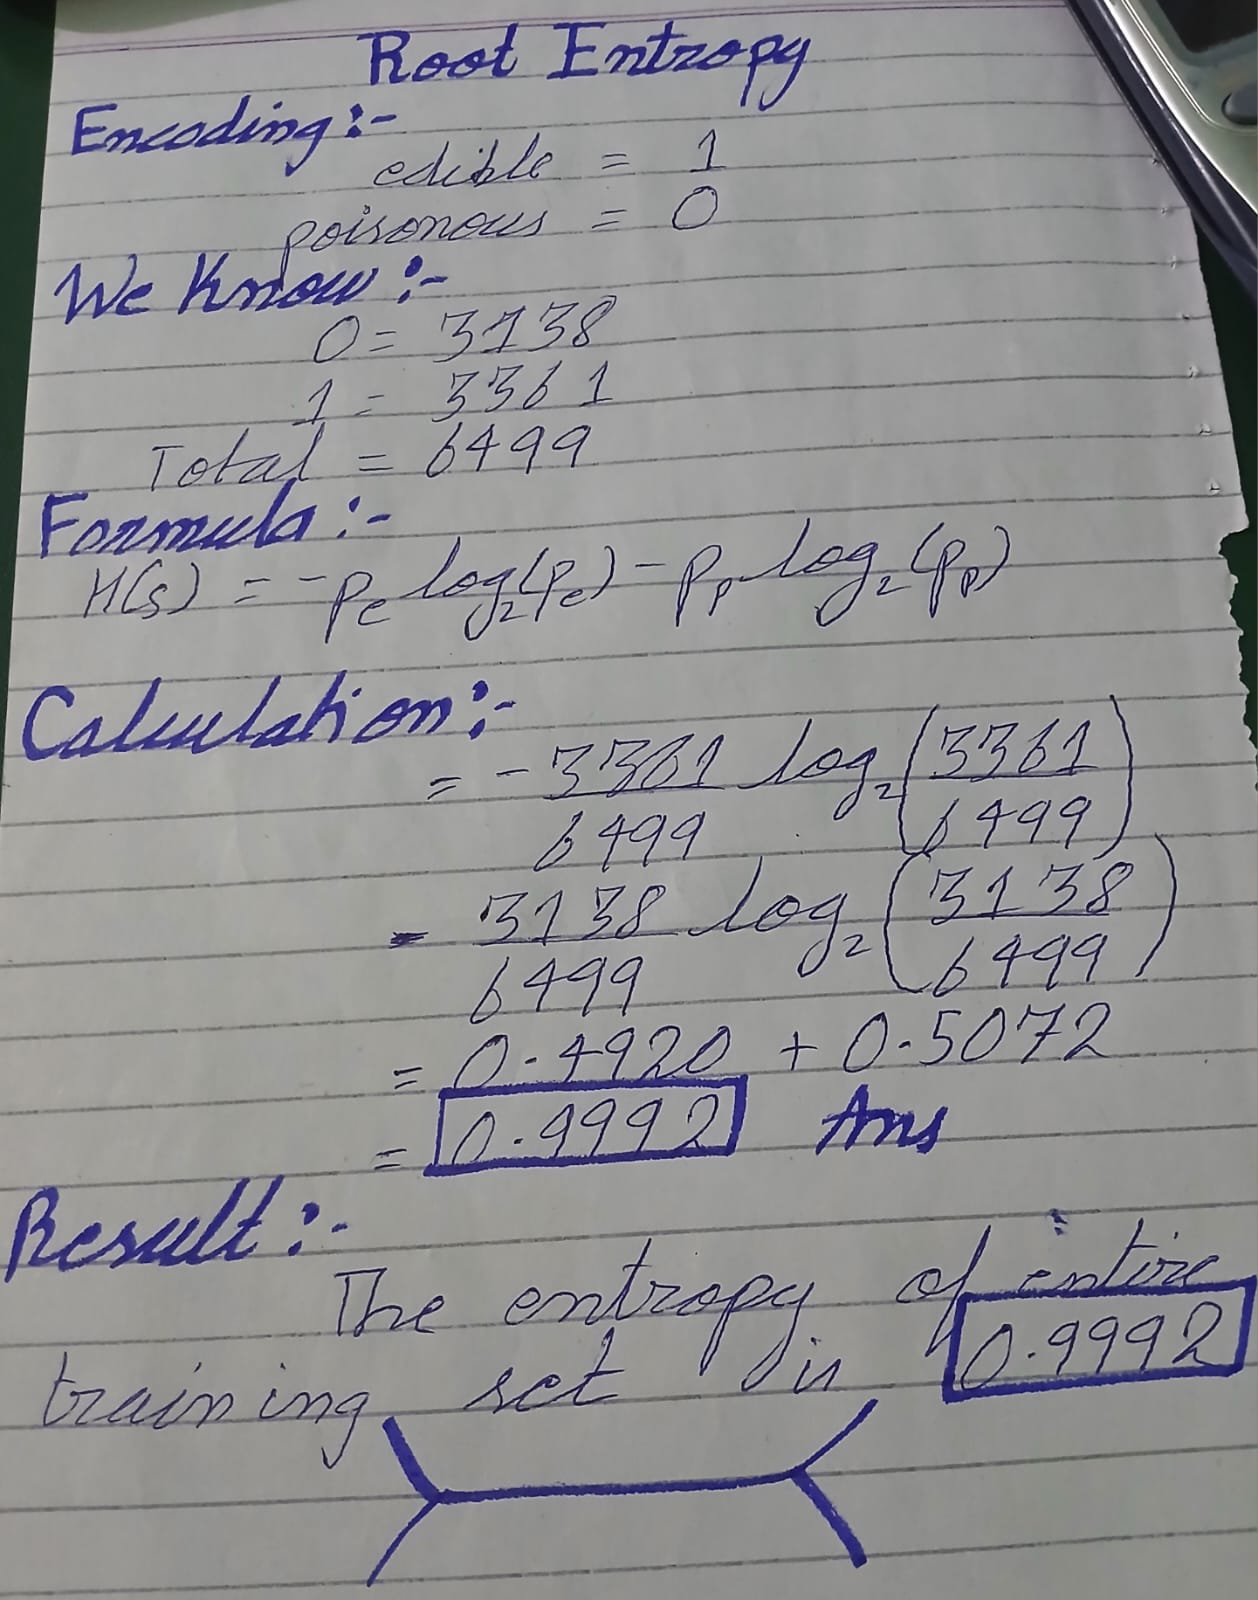

In [ ]:
# Round Entropy Calculation
p_e = count_e / total
p_p = count_p / total
entropy = -(p_e * np.log2(p_e) + p_p * np.log2(p_p))
entropy = round(entropy, 4)

In [ ]:
# Print Entropy
print("Root Entropy H(S):", entropy)

Root Entropy H(S): 0.9992


#### **Part b) of 1.2**

In [ ]:
# Get odor index automatically (safer)
odor_index = columns.index('odor') - 1

In [ ]:
# Get unique odor values
odor_values = np.unique(X_train[:, odor_index])

In [ ]:
# Print unique odor values
print("Unique Odor Values:", odor_values)

Unique Odor Values: [0 1 2 3 4 5 6 7 8]


In [ ]:
# Give the number of piosinous and edible and total count of mushroom with respect to eash unique value on Odor
print("\n=== PER ODOR VALUE CALCULATIONS ===")

for val in odor_values:
    mask = X_train[:, odor_index] == val
    subset_y = y_train[mask]

    subset_size = len(subset_y)

    counts = pd.Series(subset_y).value_counts()

    count_0 = counts.get(0, 0)
    count_1 = counts.get(1, 0)

    print("\n--------------------------------------")
    print(f"Odor = {val}")
    print(f"Total = {subset_size}")
    print(f"Count(0): {count_0}, Count(1): {count_1}")



=== PER ODOR VALUE CALCULATIONS ===

--------------------------------------
Odor = 0
Total = 206
Count(0): 206, Count(1): 0

--------------------------------------
Odor = 1
Total = 330
Count(0): 0, Count(1): 330

--------------------------------------
Odor = 2
Total = 325
Count(0): 0, Count(1): 325

--------------------------------------
Odor = 3
Total = 2804
Count(0): 98, Count(1): 2706

--------------------------------------
Odor = 4
Total = 1731
Count(0): 1731, Count(1): 0

--------------------------------------
Odor = 5
Total = 156
Count(0): 156, Count(1): 0

--------------------------------------
Odor = 6
Total = 459
Count(0): 459, Count(1): 0

--------------------------------------
Odor = 7
Total = 462
Count(0): 462, Count(1): 0

--------------------------------------
Odor = 8
Total = 26
Count(0): 26, Count(1): 0


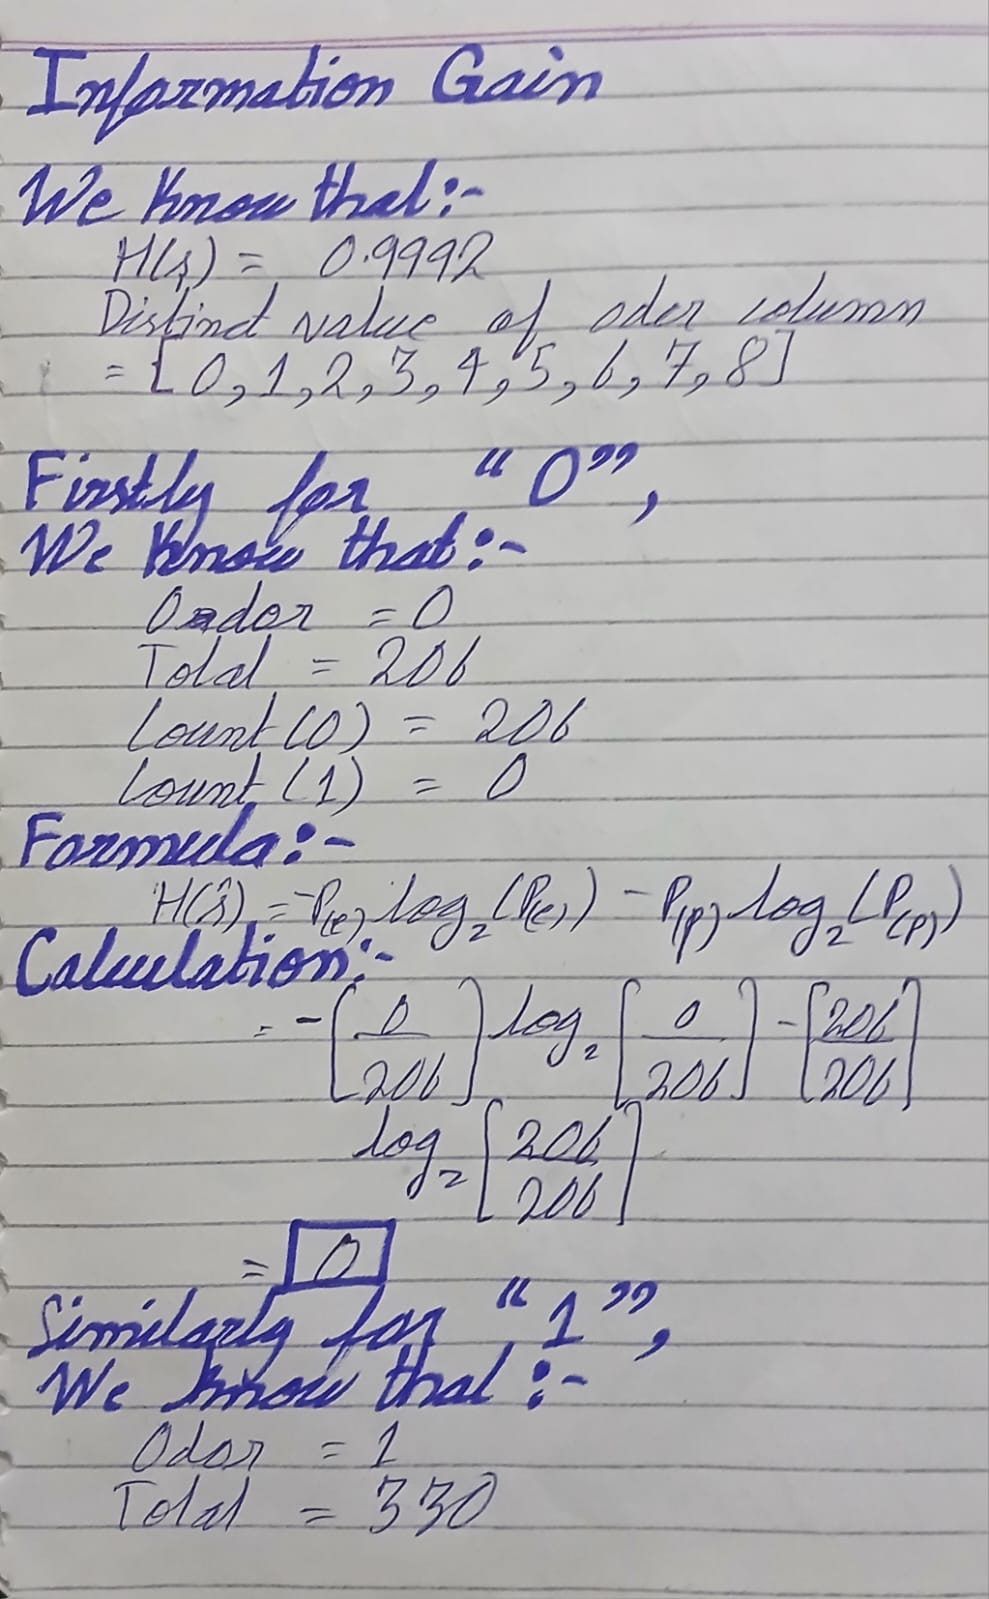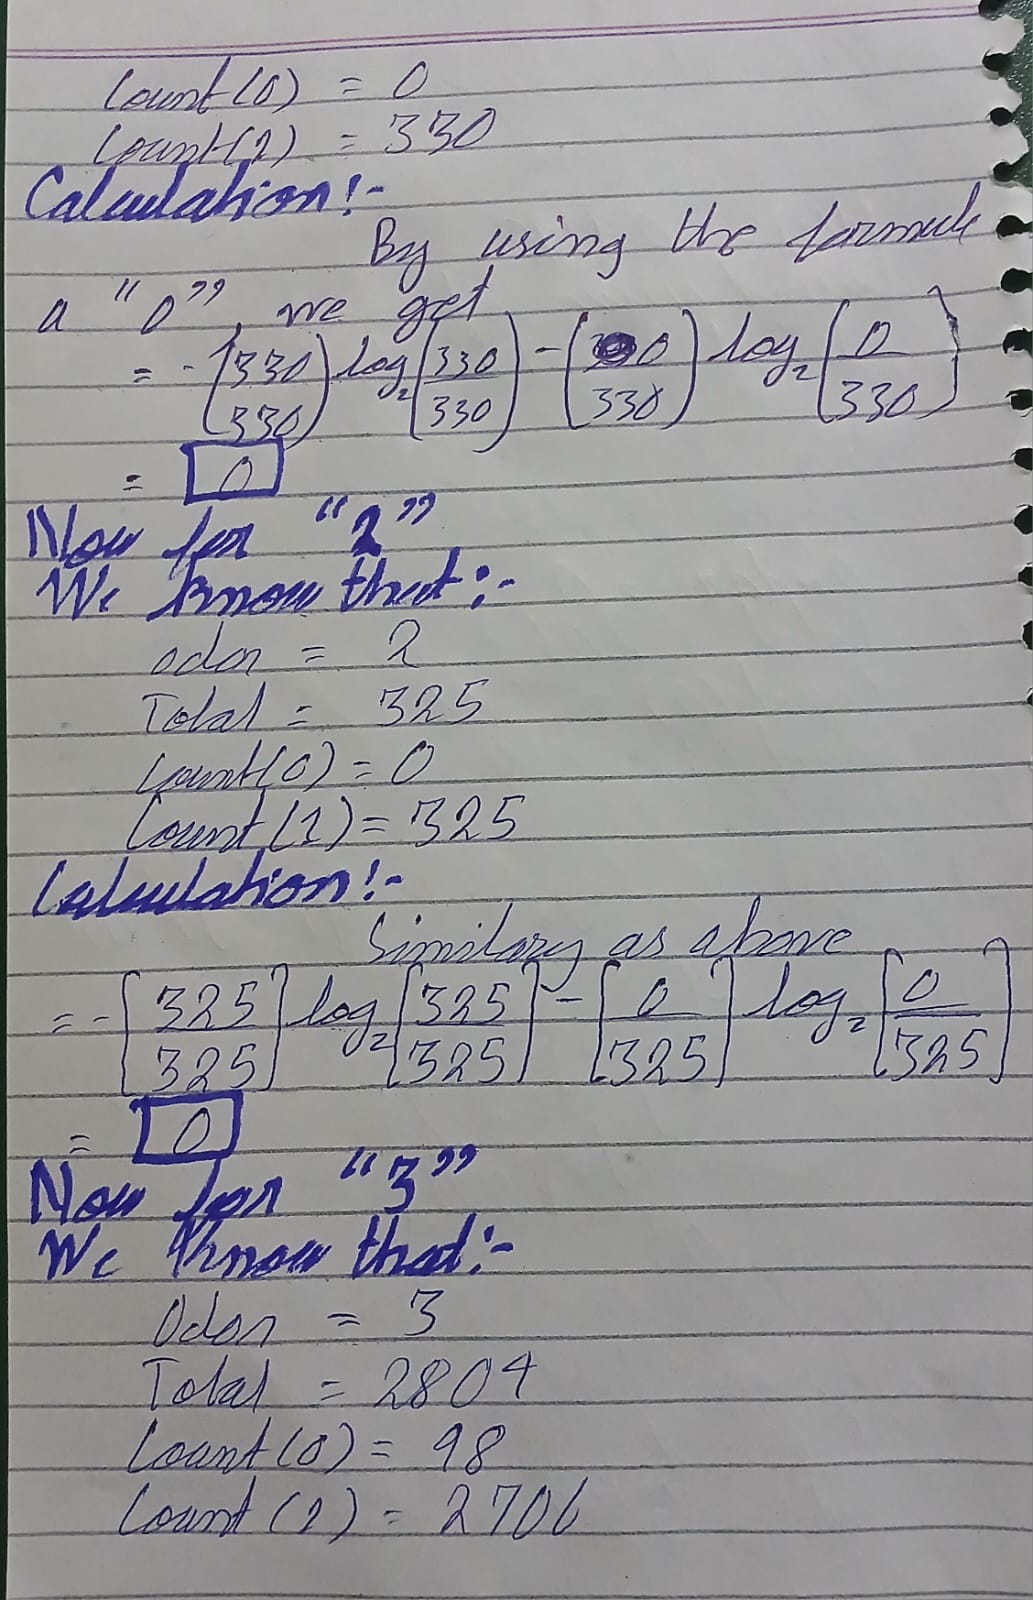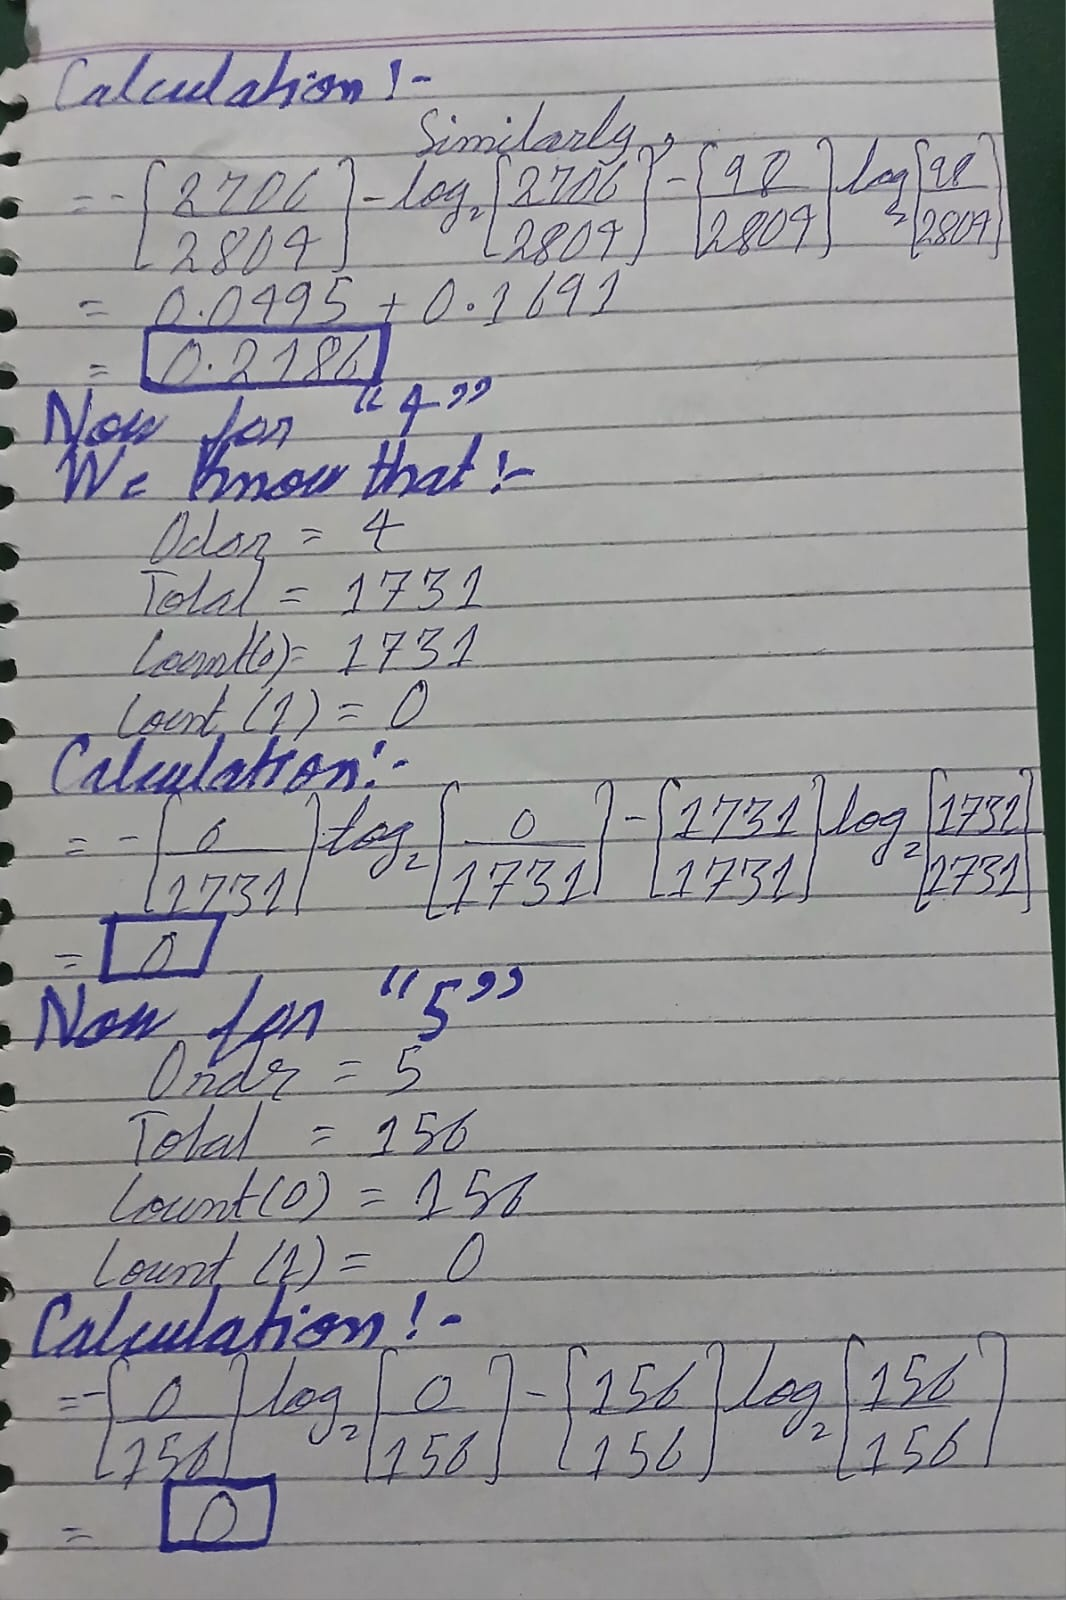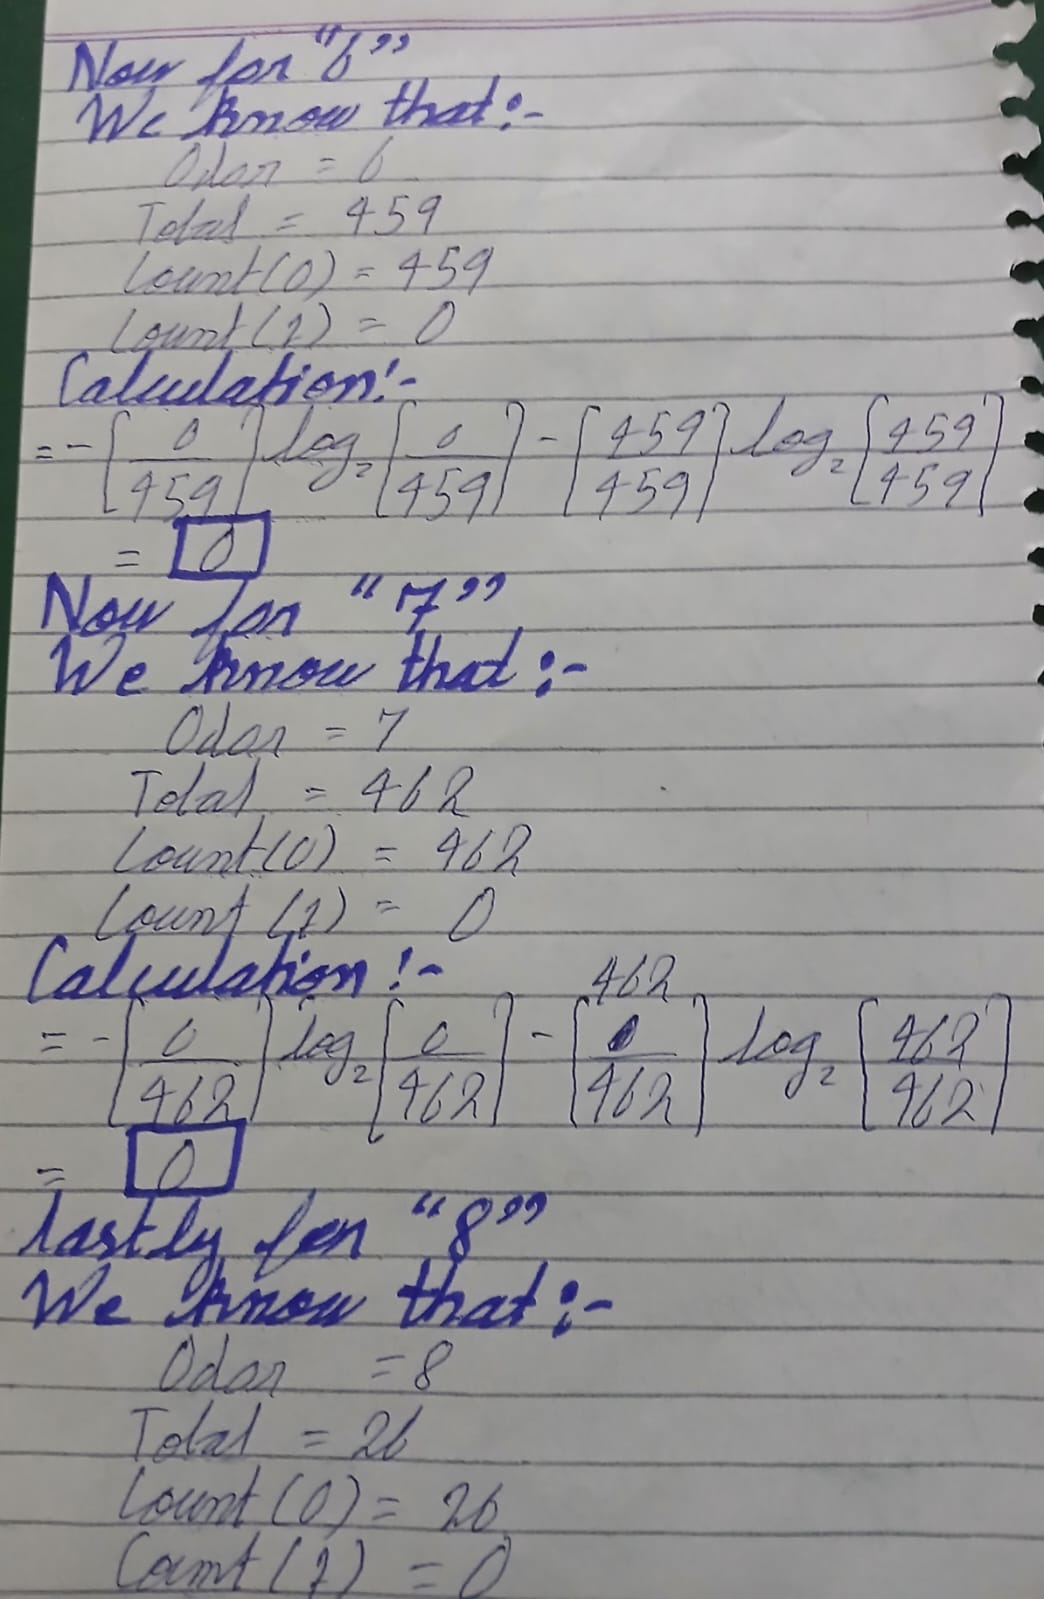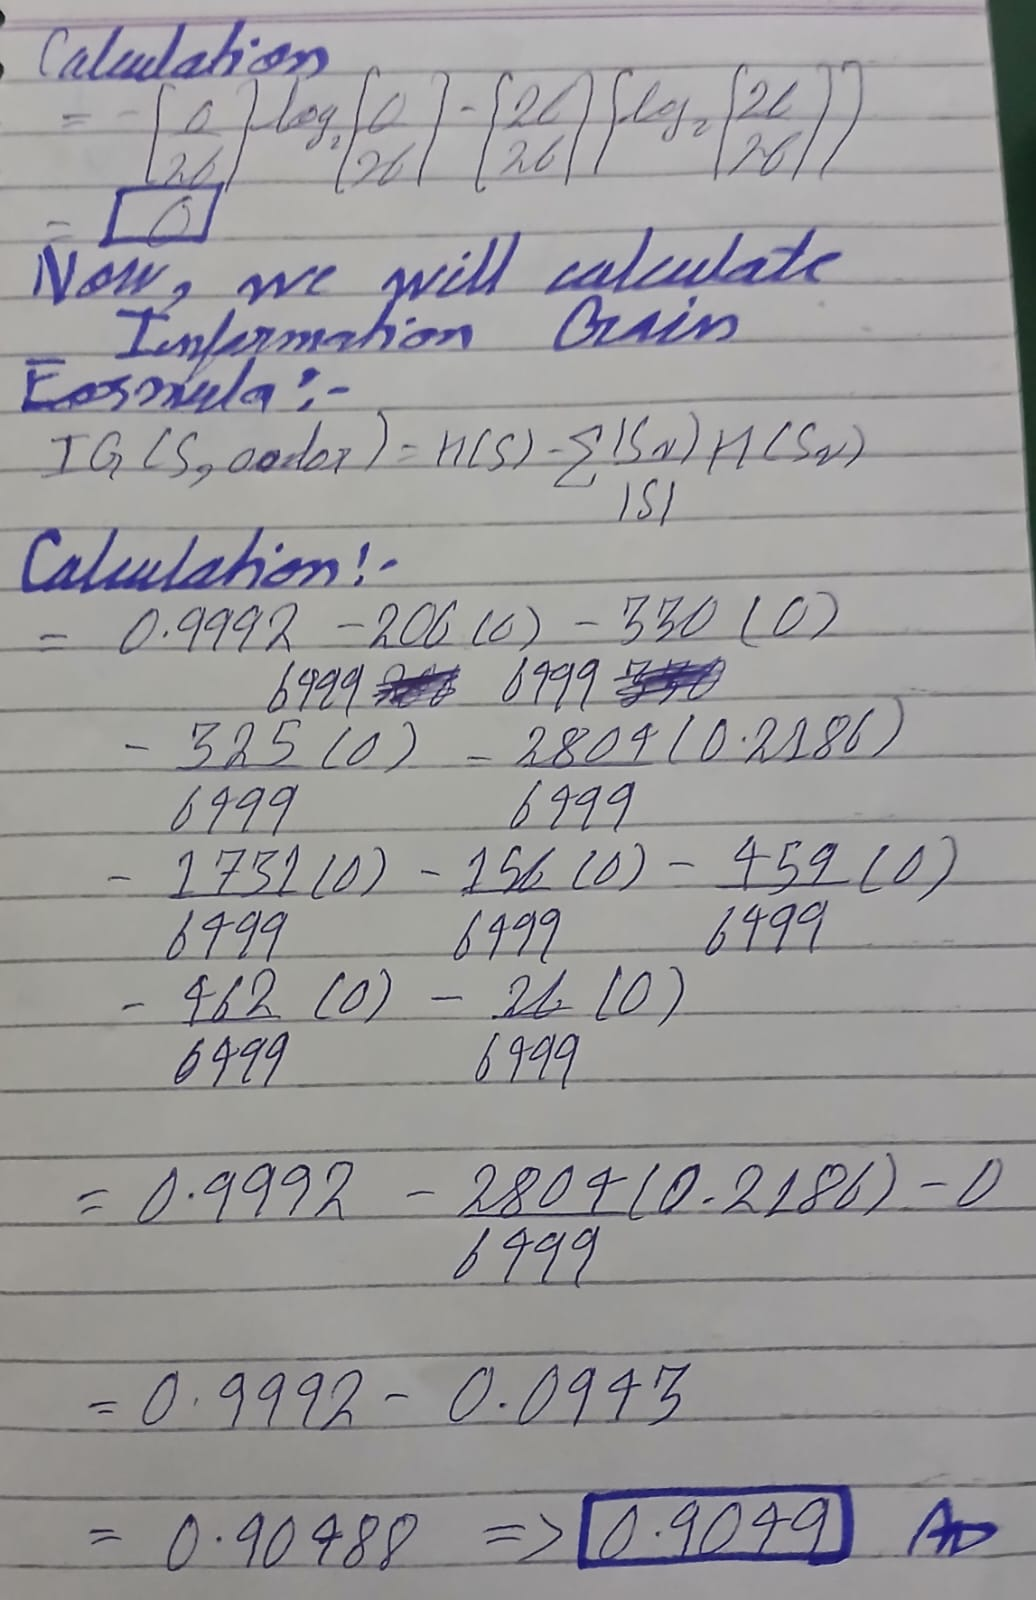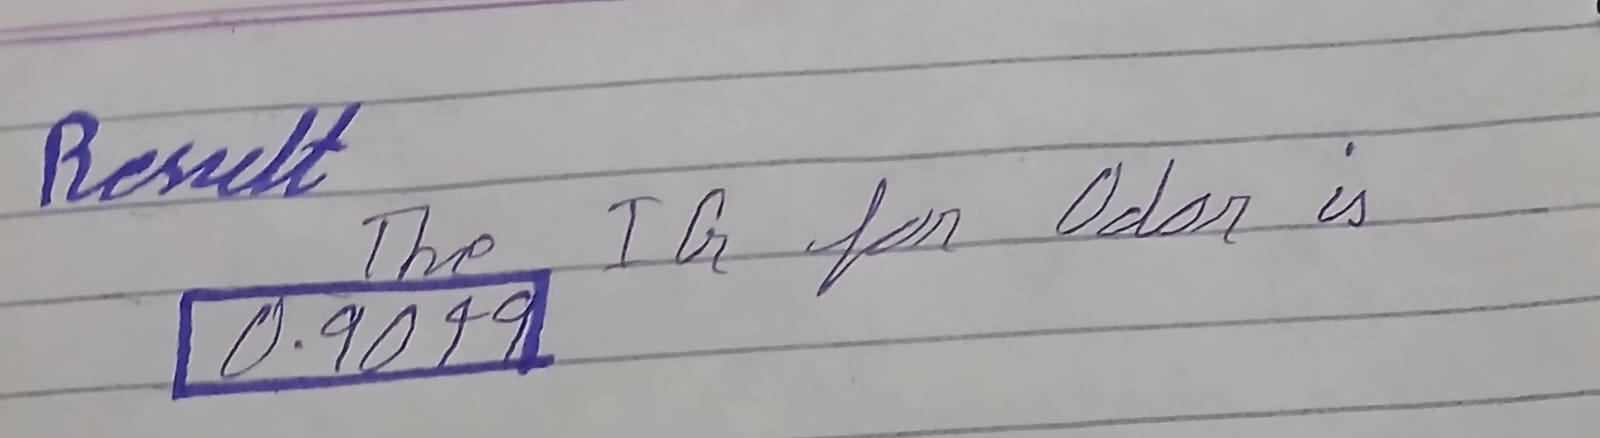

In [ ]:
# Calculation for Information Gain for Odor column
print("\n=== PER ODOR VALUE CALCULATIONS ===")

weighted_entropy = 0

for val in odor_values:
    mask = X_train[:, odor_index] == val
    subset_y = y_train[mask]

    subset_size = len(subset_y)

    counts = pd.Series(subset_y).value_counts()

    count_0 = counts.get(0, 0)
    count_1 = counts.get(1, 0)

    p0 = count_0 / subset_size if subset_size > 0 else 0
    p1 = count_1 / subset_size if subset_size > 0 else 0

    log_p0 = np.log2(p0) if p0 > 0 else 0
    log_p1 = np.log2(p1) if p1 > 0 else 0

    term0 = p0 * log_p0 if p0 > 0 else 0
    term1 = p1 * log_p1 if p1 > 0 else 0

    entropy_subset = -(term0 + term1)

    weight = subset_size / total
    contribution = weight * entropy_subset

    weighted_entropy += contribution

    print("\n--------------------------------------")
    print(f"Odor = {val}")
    print(f"p(0) = {count_0}/{subset_size} = {round(p0,4)}")
    print(f"p(1) = {count_1}/{subset_size} = {round(p1,4)}")

    print(f"log2(p0) = {round(log_p0,4)}, log2(p1) = {round(log_p1,4)}")

    print(f"p0*log2(p0) = {round(term0,4)}")
    print(f"p1*log2(p1) = {round(term1,4)}")

    print(f"H(S_v) = -({round(term0,4)} + {round(term1,4)}) = {round(entropy_subset,4)}")

    print(f"Weight = {subset_size}/{total} = {round(weight,4)}")
    print(f"Weighted term = {round(weight,4)} * {round(entropy_subset,4)} = {round(contribution,4)}")

print("\n--------------------------------------")
Odor_IG = entropy - weighted_entropy


=== PER ODOR VALUE CALCULATIONS ===

--------------------------------------
Odor = 0
p(0) = 206/206 = 1.0
p(1) = 0/206 = 0.0
log2(p0) = 0.0, log2(p1) = 0
p0*log2(p0) = 0.0
p1*log2(p1) = 0
H(S_v) = -(0.0 + 0) = -0.0
Weight = 206/6499 = 0.0317
Weighted term = 0.0317 * -0.0 = -0.0

--------------------------------------
Odor = 1
p(0) = 0/330 = 0.0
p(1) = 330/330 = 1.0
log2(p0) = 0, log2(p1) = 0.0
p0*log2(p0) = 0
p1*log2(p1) = 0.0
H(S_v) = -(0 + 0.0) = -0.0
Weight = 330/6499 = 0.0508
Weighted term = 0.0508 * -0.0 = -0.0

--------------------------------------
Odor = 2
p(0) = 0/325 = 0.0
p(1) = 325/325 = 1.0
log2(p0) = 0, log2(p1) = 0.0
p0*log2(p0) = 0
p1*log2(p1) = 0.0
H(S_v) = -(0 + 0.0) = -0.0
Weight = 325/6499 = 0.05
Weighted term = 0.05 * -0.0 = -0.0

--------------------------------------
Odor = 3
p(0) = 98/2804 = 0.035
p(1) = 2706/2804 = 0.965
log2(p0) = -4.8386, log2(p1) = -0.0513
p0*log2(p0) = -0.1691
p1*log2(p1) = -0.0495
H(S_v) = -(-0.1691 + -0.0495) = 0.2186
Weight = 2804/6499 

In [ ]:
# Display Weighted Entropy and Information Gain
print(f"Weighted Entropy = {round(weighted_entropy,4)}")
print(f"IG(S, odor) = {round(entropy,4)} - {round(weighted_entropy,4)} = {round(Odor_IG,4)}")

Weighted Entropy = 0.0943
IG(S, odor) = 0.9992 - 0.0943 = 0.9049


#### **Part c) of 1.2**

In [ ]:
# Get veil-type index automatically (safer)
veilType_index = columns.index('veil-type') - 1

In [ ]:
# Get unique veil-type values
veilType_values = np.unique(X_train[:, veilType_index])

In [ ]:
# Print unique veil-type values
print("Unique veil-type Values:", veilType_values)

Unique veil-type Values: [0]


In [ ]:
# Give the number of piosinous and edible and total count of mushroom with respect to eash unique value on veil-type
print("\n=== PER veil-type VALUE CALCULATIONS ===")

for val in veilType_values:
    mask = X_train[:, veilType_index] == val
    subset_y = y_train[mask]

    subset_size = len(subset_y)

    counts = pd.Series(subset_y).value_counts()

    count_0 = counts.get(0, 0)
    count_1 = counts.get(1, 0)

    print("\n--------------------------------------")
    print(f"veil-type = {val}")
    print(f"Total = {subset_size}")
    print(f"Count(0): {count_0}, Count(1): {count_1}")



=== PER veil-type VALUE CALCULATIONS ===

--------------------------------------
veil-type = 0
Total = 6499
Count(0): 3138, Count(1): 3361


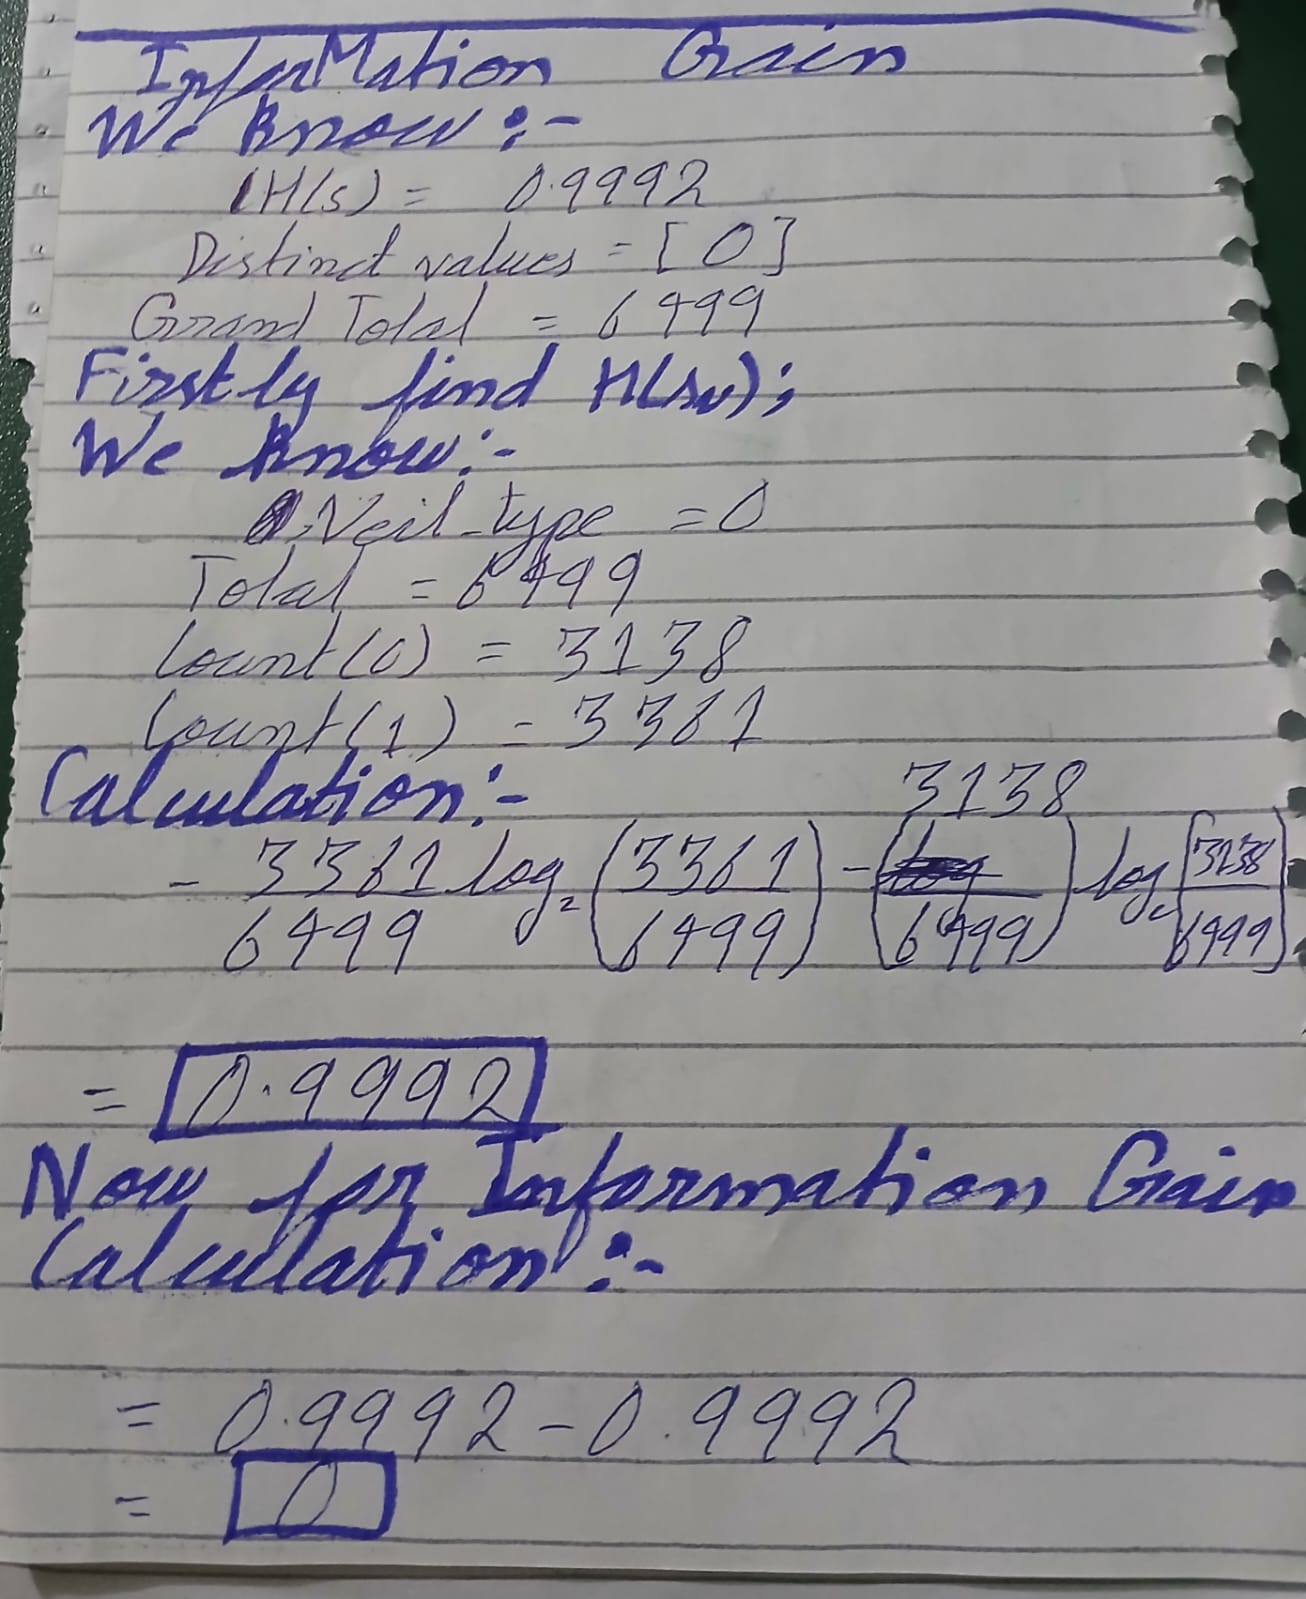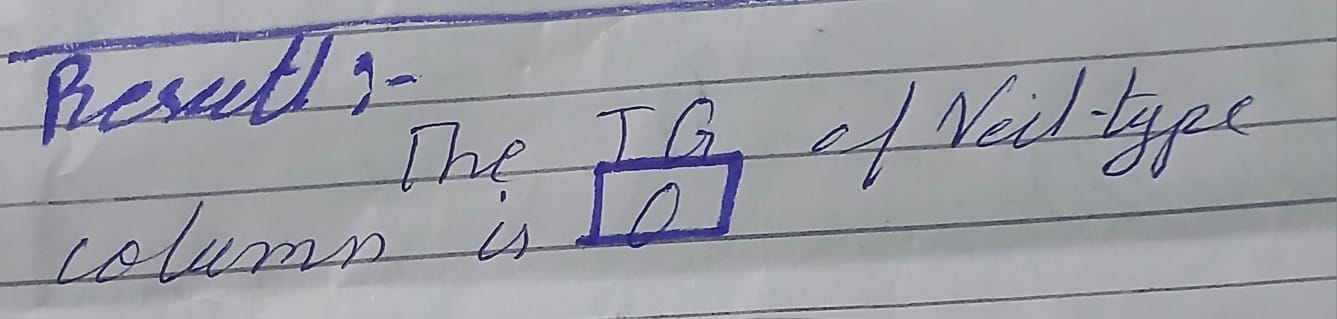

In [ ]:
# Calculation for Information Gain for veil-type column
print("\n=== PER veil-type VALUE CALCULATIONS ===")

weighted_entropy = 0

for val in veilType_values:
    mask = X_train[:, veilType_index] == val
    subset_y = y_train[mask]

    subset_size = len(subset_y)

    counts = pd.Series(subset_y).value_counts()

    count_0 = counts.get(0, 0)
    count_1 = counts.get(1, 0)

    p0 = count_0 / subset_size if subset_size > 0 else 0
    p1 = count_1 / subset_size if subset_size > 0 else 0

    log_p0 = np.log2(p0) if p0 > 0 else 0
    log_p1 = np.log2(p1) if p1 > 0 else 0

    term0 = p0 * log_p0 if p0 > 0 else 0
    term1 = p1 * log_p1 if p1 > 0 else 0

    entropy_subset = -(term0 + term1)

    weight = subset_size / total
    contribution = weight * entropy_subset

    weighted_entropy += contribution

    print("\n--------------------------------------")
    print(f"veil-type = {val}")
    print(f"p(0) = {count_0}/{subset_size} = {round(p0,4)}")
    print(f"p(1) = {count_1}/{subset_size} = {round(p1,4)}")

    print(f"log2(p0) = {round(log_p0,4)}, log2(p1) = {round(log_p1,4)}")

    print(f"p0*log2(p0) = {round(term0,4)}")
    print(f"p1*log2(p1) = {round(term1,4)}")

    print(f"H(S_v) = -({round(term0,4)} + {round(term1,4)}) = {round(entropy_subset,4)}")

    print(f"Weight = {subset_size}/{total} = {round(weight,4)}")
    print(f"Weighted term = {round(weight,4)} * {round(entropy_subset,4)} = {round(contribution,4)}")

print("\n--------------------------------------")
veiltype_IG = entropy - weighted_entropy


=== PER veil-type VALUE CALCULATIONS ===

--------------------------------------
veil-type = 0
p(0) = 3138/6499 = 0.4828
p(1) = 3361/6499 = 0.5172
log2(p0) = -1.0504, log2(p1) = -0.9513
p0*log2(p0) = -0.5072
p1*log2(p1) = -0.492
H(S_v) = -(-0.5072 + -0.492) = 0.9992
Weight = 6499/6499 = 1.0
Weighted term = 1.0 * 0.9992 = 0.9992

--------------------------------------


In [ ]:
# Display Weighted Entropy and Information Gain
print(f"Weighted Entropy = {round(weighted_entropy,4)}")
print(f"IG(S, veil-type) = {round(entropy,4)} - {round(weighted_entropy,4)} = {round(veiltype_IG,4)}")

Weighted Entropy = 0.9992
IG(S, veil-type) = 0.9992 - 0.9992 = 0.0


#### ***Comparison of Attributes (Odor vs Veil-type)***

Information Gain of **odor**:
IG(S, odor) = 0.9992 − 0.0943 = 0.9049

Information Gain of **veil-type**:
IG(S, veil-type) = 0.9992 − 0.9992 = 0.0000

#### ***Conclusion***

The ID3 algorithm selects the attribute with the highest Information Gain. Since the Information Gain of **odor (0.9049)** is significantly higher than that of **veil-type (0.0000)**, **odor is selected as the root node**.

This is because odor provides the maximum reduction in entropy and results in the best separation of the dataset.

### **1.3 ID3 Implementation**

In [ ]:
# Entropy Function

def compute_entropy(y):
    """
    Compute the Shannon entropy H(S) of a set of class labels.

    Parameters:
    y (numpy.ndarray): 1-D array of class labels.

    Returns:
    float: Entropy value computed as:
           H(S) = - Σ (p_i * log2(p_i)),
           where p_i is the probability of each class.

    Note:
    Handles the edge case where a class probability is 0 by skipping log2(0).
    """
    values, counts = np.unique(y, return_counts=True)
    probs = counts / len(y)

    entropy = 0
    for p in probs:
        if p > 0:
            entropy -= p * np.log2(p)

    return entropy

In [ ]:
# Information Gain Function

def compute_information_gain(X, y, feature_index):
    """
    Compute the Information Gain IG(S, A) for a given feature.

    Parameters:
    X (numpy.ndarray): 2-D array of feature values (shape: n_samples x n_features).
    y (numpy.ndarray): 1-D array of class labels.
    feature_index (int): Index of the feature column for which IG is computed.

    Returns:
    float: Information Gain value calculated as:
           IG(S, A) = H(S) - Σ (|S_v| / |S|) * H(S_v),
           where S_v is the subset of samples where feature A takes value v.

    Description:
    - Computes the entropy of the full dataset (parent entropy).
    - Splits the dataset based on each unique value of the selected feature.
    - Computes the entropy of each subset.
    - Calculates the weighted sum of subset entropies.
    - Returns the reduction in entropy (Information Gain).
    """
    parent_entropy = compute_entropy(y)

    values = np.unique(X[:, feature_index])
    weighted_entropy = 0

    for v in values:
        subset_y = y[X[:, feature_index] == v]
        weight = len(subset_y) / len(y)

        weighted_entropy += weight * compute_entropy(subset_y)

    return parent_entropy - weighted_entropy

In [ ]:
# Best Feature Function
def best_feature(X, y):
    """
    Select the feature index with the highest Information Gain.

    Parameters:
    X (numpy.ndarray): 2-D array of feature values (shape: n_samples x n_features).
    y (numpy.ndarray): 1-D array of class labels.

    Returns:
    int: Index of the feature that has the highest Information Gain.

    Description:
    - Iterates over all feature columns in X.
    - Computes Information Gain for each feature using compute_information_gain().
    - Returns the index of the feature with the maximum Information Gain.
    """

    gains = [compute_information_gain(X, y, i) for i in range(X.shape[1])]
    return np.argmax(gains)

In [ ]:
# Build Tree Function

def build_tree(X, y, feature_names, depth=0, max_depth=10):
    """
    Build a decision tree using the ID3 algorithm.

    Parameters:
    X (numpy.ndarray): 2-D array of feature values (shape: n_samples x n_features).
    y (numpy.ndarray): 1-D array of class labels corresponding to X.
    feature_names (list): List of feature names aligned with columns of X.
    depth (int, optional): Current depth of the tree (default is 0).
    max_depth (int, optional): Maximum allowed depth of the tree (default is 10).

    Returns:
    dict or int: A decision tree represented as a nested dictionary:
                 - Internal node: {"feature": feature_index, "branches": {value: subtree}}
                 - Leaf node: class label (int).

    Description:
    - Computes the majority class for fallback decisions.
    - If all labels are identical, returns that label (pure node).
    - If no features remain or max_depth is reached, returns the majority class.
    - Selects the best feature using Information Gain.
    - Splits the data on each unique value of the selected feature.
    - Removes the used feature from the subset for recursive calls.
    - Handles empty splits by assigning the majority class.
    - Recursively builds subtrees for each branch.
    """

    # Majority class (used for fallback)
    majority_class = np.bincount(y).argmax()

    # Base case 1: pure node
    if len(np.unique(y)) == 1:
        return y[0]

    # Base case 2: no features or depth limit
    if X.shape[1] == 0 or depth == max_depth:
        return majority_class

    # Select best feature
    feature_index = best_feature(X, y)

    tree = {"feature": feature_index, "branches": {}}

    values = np.unique(X[:, feature_index])

    for v in values:
        idx = X[:, feature_index] == v

        X_sub = np.delete(X[idx], feature_index, axis=1)
        y_sub = y[idx]

        # Handle empty split (VERY IMPORTANT)
        if len(y_sub) == 0:
            tree["branches"][v] = majority_class
            continue

        new_feature_names = (
            feature_names[:feature_index] +
            feature_names[feature_index+1:]
        )

        subtree = build_tree(
            X_sub,
            y_sub,
            new_feature_names,
            depth + 1,
            max_depth
        )

        tree["branches"][v] = subtree

    return tree

### **1.4 Prediction & Evaluation**

In [ ]:
# Helper Function For Prediction function

def predict_one(tree, x, default_class):
    """
    Predict the class label for a single sample using the decision tree.

    Parameters:
    tree (dict or int): The decision tree represented as a nested dictionary,
                        or a class label if it is a leaf node.
    x (numpy.ndarray): A single sample (1-D array of feature values).
    default_class (int): Default class label to return if an unseen feature value is encountered.

    Returns:
    int: Predicted class label for the given sample.

    Description:
    - Traverses the tree recursively based on feature values in x.
    - If a leaf node is reached, returns the class label.
    - If the feature value is not found in the tree branches,
      returns the default_class.
    """
    if not isinstance(tree, dict):
        return tree

    feature = tree["feature"]
    value = x[feature]

    if value in tree["branches"]:
        return predict_one(tree["branches"][value], x, default_class)
    else:
        return default_class

In [ ]:
# Predict Function

def predict(tree, X, default_class):
    """
    Predict class labels for a dataset using the decision tree.

    Parameters:
    tree (dict or int): The trained decision tree.
    X (numpy.ndarray): 2-D array of test samples (shape: n_samples x n_features).
    default_class (int): Default class label used for unseen feature values.

    Returns:
    numpy.ndarray: Array of predicted class labels for all samples in X.

    Description:
    - Applies predict_one() to each sample in X.
    - Returns all predictions as a NumPy array.
    """
    return np.array([predict_one(tree, x, default_class) for x in X])

In [ ]:
# Get Feature names from Column
feature_names = columns[1:]

In [ ]:
# Determine the majority class from training data (used as default prediction)
default_class = np.bincount(y_train).argmax()

In [ ]:
# Build the decision tree using training data
tree = build_tree(X_train, y_train, feature_names)

In [ ]:
# Predict class labels for test data
y_pred = predict(tree, X_test, default_class)

In [ ]:
# Compute accuracy manually: correct predictions / total samples
accuracy = np.sum(y_pred == y_test) / len(y_test)

In [ ]:
# Display accuracy
print("Accuracy:", accuracy)

Accuracy: 0.9864615384615385


In [ ]:
# CONFUSION MATRIX

def confusion_matrix(y_true, y_pred, positive_label):
    """
    Compute a 2x2 confusion matrix.

    Parameters:
    y_true (numpy.ndarray): True class labels.
    y_pred (numpy.ndarray): Predicted class labels.
    positive_label (int): The label considered as positive class.

    Returns:
    numpy.ndarray: Confusion matrix in the form:
                   [[TP, FP],
                    [FN, TN]]
    """
    TP = np.sum((y_true == positive_label) & (y_pred == positive_label))
    TN = np.sum((y_true != positive_label) & (y_pred != positive_label))
    FP = np.sum((y_true != positive_label) & (y_pred == positive_label))
    FN = np.sum((y_true == positive_label) & (y_pred != positive_label))

    return np.array([[TP, FP], [FN, TN]])

In [ ]:
# define positive class
positive_label = encoders['class']['p']

In [ ]:
# Print Positive Labels
print("Positive Label:", positive_label)

Positive Label: 0


In [ ]:
# compute confusion matrix
cm = confusion_matrix(y_test, y_pred, positive_label)

In [ ]:
# Display Confusion Matrix
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[756   0]
 [ 22 847]]


In [ ]:
# Print as formatted table
print("\nConfusion Matrix (Formatted):")
print("            Predicted")
print("            P       N")
print(f"Actual P    {cm[0][0]}     {cm[0][1]}")
print(f"Actual N    {cm[1][0]}      {cm[1][1]}")


Confusion Matrix (Formatted):
            Predicted
            P       N
Actual P    756     0
Actual N    22      847


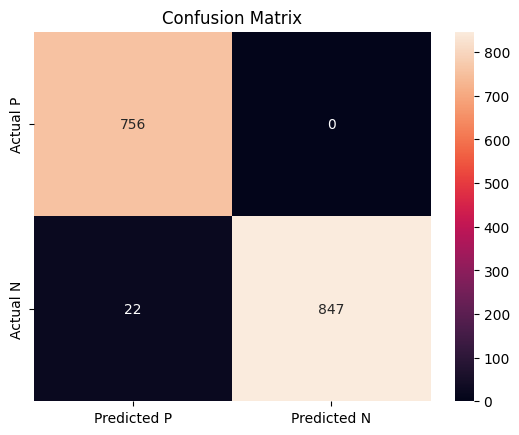

In [ ]:
# Display Heatmap

plt.figure()
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=["Predicted P", "Predicted N"],
            yticklabels=["Actual P", "Actual N"])

plt.title("Confusion Matrix")
plt.show()

### Model Performance Analysis

The model achieves very high accuracy (approximately 98.64%), indicating excellent overall performance.

From the confusion matrix, the number of correct predictions is very high, with 756 true positives and 847 true negatives. The model makes no false positive errors, meaning no edible mushrooms are incorrectly classified as poisonous, which is very important for safety.

There are only 22 false negatives, indicating a very small number of misclassifications. Overall, the model is highly reliable and performs very well on this dataset.

## **Task 02 — K-Means Clustering**

### **2.1 Data Preprocessing**

In [ ]:
# Install KaggleHub Library
!pip install kagglehub

In [ ]:
# Import KaggleHub
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

In [ ]:
# Download dataset
path = kagglehub.dataset_download("vjchoudhary7/customer-segmentation-tutorial-in-python")

Using Colab cache for faster access to the 'customer-segmentation-tutorial-in-python' dataset.


In [ ]:
# Get Path of Downloaded Dataset
print("Dataset path:", path)

Dataset path: /kaggle/input/customer-segmentation-tutorial-in-python


In [ ]:
# Find CSV file inside downloaded folder
files = os.listdir(path)
print("Files:", files)

Files: ['Mall_Customers.csv']


In [ ]:
# Load CSV dataset
df = pd.read_csv(os.path.join(path, "Mall_Customers.csv"))

In [ ]:
# Print first 5 rows, dataShape and missing values
print(df.head())
print("Shape:", df.shape)
print("\nMissing values:\n", df.isnull().sum())

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40
Shape: (200, 5)

Missing values:
 CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


In [ ]:
# Extract only required features
X = df[['Annual Income (k$)', 'Spending Score (1-100)']].values

In [ ]:
# Display Feature Shape
print("Feature shape:", X.shape)

Feature shape: (200, 2)


In [ ]:
# Compute mean and std
mean = np.mean(X, axis=0)
std = np.std(X, axis=0)

In [ ]:
# Feature Scaling (Z-score) Standardize
X_scaled = (X - mean) / std

In [ ]:
# Display Mean, STD, and Z-score
print("Mean:", mean)
print("STD:", std)
print("Z-score:\n", X_scaled)

Mean: [60.56 50.2 ]
STD: [26.19897708 25.75888196]
Z-score:
 [[-1.73899919 -0.43480148]
 [-1.73899919  1.19570407]
 [-1.70082976 -1.71591298]
 [-1.70082976  1.04041783]
 [-1.66266033 -0.39597992]
 [-1.66266033  1.00159627]
 [-1.62449091 -1.71591298]
 [-1.62449091  1.70038436]
 [-1.58632148 -1.83237767]
 [-1.58632148  0.84631002]
 [-1.58632148 -1.4053405 ]
 [-1.58632148  1.89449216]
 [-1.54815205 -1.36651894]
 [-1.54815205  1.04041783]
 [-1.54815205 -1.44416206]
 [-1.54815205  1.11806095]
 [-1.50998262 -0.59008772]
 [-1.50998262  0.61338066]
 [-1.43364376 -0.82301709]
 [-1.43364376  1.8556706 ]
 [-1.39547433 -0.59008772]
 [-1.39547433  0.88513158]
 [-1.3573049  -1.75473454]
 [-1.3573049   0.88513158]
 [-1.24279661 -1.4053405 ]
 [-1.24279661  1.23452563]
 [-1.24279661 -0.7065524 ]
 [-1.24279661  0.41927286]
 [-1.20462718 -0.74537397]
 [-1.20462718  1.42863343]
 [-1.16645776 -1.7935561 ]
 [-1.16645776  0.88513158]
 [-1.05194947 -1.7935561 ]
 [-1.05194947  1.62274124]
 [-1.05194947 -1.4053

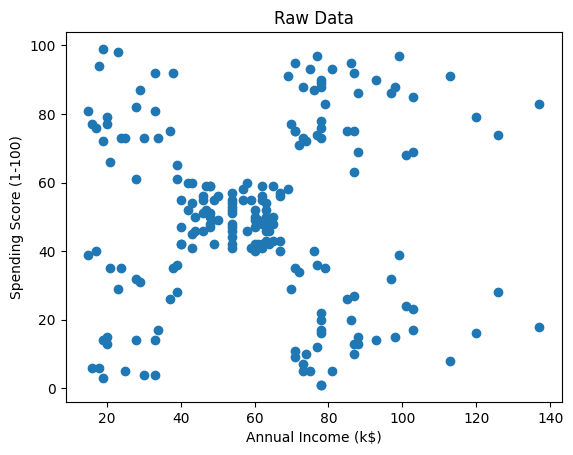

In [ ]:
# Raw Scatter Plot

plt.figure()
plt.scatter(X[:,0], X[:,1])
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Raw Data")
plt.show()

### **2.2 K-Means Implementation**

In [ ]:
# Function for initializeing centroids

def initialize_centroids(X, K, seed=42):
    """
    Randomly select K distinct points as initial centroids.

    Parameters:
    X (numpy.ndarray): Data points
    K (int): Number of clusters
    seed (int): Random seed

    Returns:
    numpy.ndarray: Initial centroids (K, n_features)
    """
    np.random.seed(seed)
    indices = np.random.choice(len(X), K, replace=False)
    return X[indices]

In [ ]:
# Function for assigning clusters

def assign_clusters(X, centroids):
    """
    Assign each point to nearest centroid using Euclidean distance.

    Returns:
    numpy.ndarray: Cluster labels
    """
    distances = np.linalg.norm(X[:, np.newaxis] - centroids, axis=2)
    return np.argmin(distances, axis=1)

In [ ]:
# Function for updating centroid

def update_centroids(X, labels, K, prev_centroids):
    """
    Update centroids as mean of assigned points.

    Handles empty clusters by keeping previous centroid.
    """
    new_centroids = []

    for k in range(K):
        points = X[labels == k]

        if len(points) == 0:
            new_centroids.append(prev_centroids[k])
        else:
            new_centroids.append(np.mean(points, axis=0))

    return np.array(new_centroids)

In [ ]:
# Function for computing distortion

def compute_distortion(X, labels, centroids):
    """
    Compute total distortion (sum of squared distances).
    """
    total = 0
    for i in range(len(X)):
        total += np.sum((X[i] - centroids[labels[i]])**2)
    return total

In [ ]:
# Function for running K-Mean clustering

def run_kmeans(X, K, max_iters=300, tol=1e-4, seed=42):
    """
    Run full K-Means algorithm.

    Returns:
    labels, centroids, distortion_history
    """
    centroids = initialize_centroids(X, K, seed)
    distortion_history = []

    for _ in range(max_iters):
        labels = assign_clusters(X, centroids)
        new_centroids = update_centroids(X, labels, K, centroids)

        distortion = compute_distortion(X, labels, new_centroids)
        distortion_history.append(distortion)

        if np.linalg.norm(new_centroids - centroids) < tol:
            break

        centroids = new_centroids

    return labels, centroids, distortion_history

In [ ]:
# Run K-Means (K = 5)
K = 5
labels, centroids, distortions = run_kmeans(X_scaled, K)

In [ ]:
# Print Final Distortion
print("Final Distortion:", distortions[-1])

Final Distortion: 65.57885579985044


In [ ]:
# Convert Centroids to Original Scale
centroids_original = centroids * std + mean

In [ ]:
# Print Centroids at original scale
print("Centroids (Original Scale):\n", centroids_original)

Centroids (Original Scale):
 [[55.0875     49.7125    ]
 [25.72727273 79.36363636]
 [26.30434783 20.91304348]
 [86.53846154 82.12820513]
 [87.75       17.58333333]]


### **2.3 Choosing K (Elbow)**

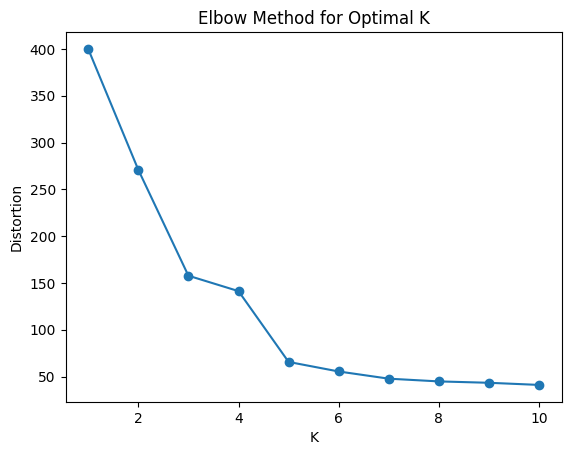

In [ ]:
# Choseing value of K repeatdly
K_values = range(1, 11)
dist_list = []

for k in K_values:
    _, _, d = run_kmeans(X_scaled, k)
    dist_list.append(d[-1])

plt.figure()
plt.plot(K_values, dist_list, marker='o')
plt.xlabel("K")
plt.ylabel("Distortion")
plt.title("Elbow Method for Optimal K")
plt.show()

***`The elbow point is observed at K = 5, where the distortion drops sharply up to this point and then begins to decrease more gradually. This indicates that adding more clusters beyond K = 5 provides diminishing improvement. Therefore, K = 5 is selected as the optimal number of clusters.`***

### **2.4 Visualization & Interpretation**

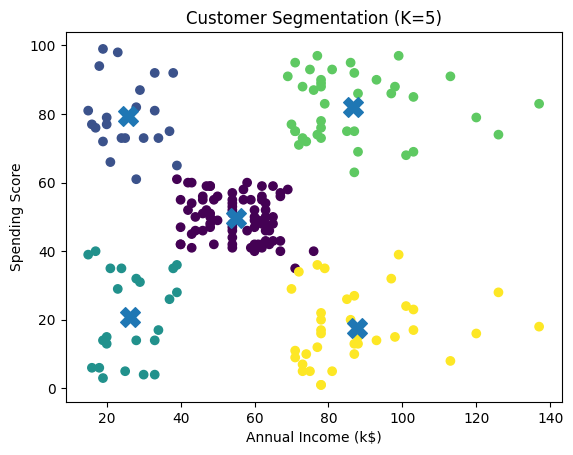

In [ ]:
# Clustered Scatter Plot
plt.figure()
plt.scatter(X[:,0], X[:,1], c=labels)

plt.scatter(
    centroids_original[:,0],
    centroids_original[:,1],
    marker='X',
    s=200
)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score")
plt.title("Customer Segmentation (K=5)")
plt.show()

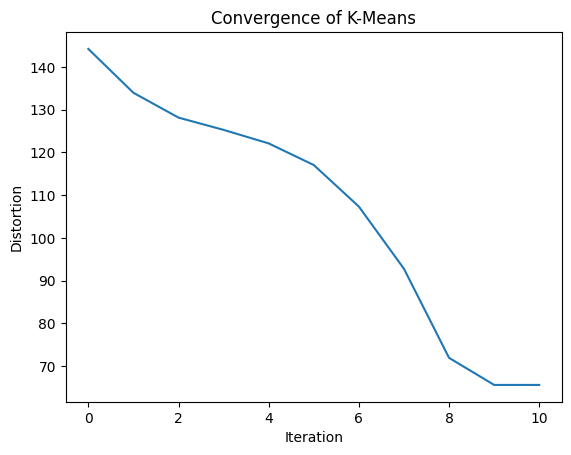

In [ ]:
#Convergence Plot
plt.figure()
plt.plot(distortions)
plt.xlabel("Iteration")
plt.ylabel("Distortion")
plt.title("Convergence of K-Means")
plt.show()

Cluster 1: Customers with low annual income and low spending score, representing budget-conscious or less active shoppers.

Cluster 2: Customers with high annual income and high spending score, representing premium or high-value customers who are important for targeted marketing.

Cluster 3: Customers with high income but low spending score, indicating potential customers who have the capacity to spend but are currently less engaged.

Cluster 4: Customers with low income but relatively high spending score, suggesting impulsive or enthusiastic buyers despite limited income.

Cluster 5: Customers with moderate income and moderate spending score, representing average or balanced shoppers.

These clusters reveal distinct customer segments, allowing businesses to design targeted marketing strategies, improve customer engagement, and maximize revenue.